<div align="center">

<img src="../img/logo.png" width="380">

# Predicción de Inventario

**Proyecto de Machine Learning — Trazos y Hojas**

</div>

---

### Business Case

**Problema de negocio:** la papelería Trazos y Hojas necesita anticipar cuántas unidades de producto va a necesitar en inventario, para evitar tanto roturas de stock como sobre-stock inmovilizando capital.

**Objetivo de modelado:** predecir, para cada producto y cada día, cuántas unidades se venderán. Es un problema de **regresión supervisada** sobre una serie temporal de ventas.

**Alcance de este notebook:** exploración y preparación de los datos (EDA orientado al modelado), a cargo de Desarrolladora 2.

<h2 style="color:#4A6035;">Exploración inicial de los datos</h2>

Primer vistazo al dataset en bruto tal y como llega del TPV: dimensiones, tipos de dato, missings y primeros registros.

In [1]:
# --- Librerías ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# --- Paleta de colores de la marca Trazos y Hojas ---
VERDE_OSCURO = '#4A6035'
MARRON       = '#8F7C52'
VERDE_CLARO  = '#7D955B'
CREMA        = '#EFE6D2'
MOSTAZA      = '#D9A441'
NARANJA      = '#D9824A'

PALETA_MARCA = [VERDE_OSCURO, MARRON, VERDE_CLARO, MOSTAZA, NARANJA, CREMA]
sns.set_palette(sns.color_palette(PALETA_MARCA))
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=PALETA_MARCA)

In [2]:
# sep=';' -> el archivo usa punto y coma como separador
# encoding='utf-8' -> para que tildes y eñes se lean bien
df = pd.read_csv('../data_sample/DatosBrutos (1).csv', sep=';', encoding='utf-8')

print(f'Filas: {df.shape[0]}')
print(f'Columnas: {df.shape[1]}')

Filas: 11613
Columnas: 20


In [3]:
df.columns.tolist()

['Producto',
 'Cantidad',
 'Categoría',
 'Fecha/Hora',
 'Valor del Descuento',
 'Motivo del Descuento',
 'Ventas NETAS',
 'Tipo de Venta',
 'Opción de Comer',
 'Código Fiscal',
 'Impuesto',
 'Ventas TOTALES',
 'Precio de Coste',
 'Margen',
 'Método de Pago',
 'Nominal',
 'A/C Ref',
 'Notas',
 'Identificación del Cliente',
 'ProductId']

In [4]:
# object = texto | float64 = decimal | int64 = entero
df.dtypes

Producto                          str
Cantidad                      float64
Categoría                         str
Fecha/Hora                        str
Valor del Descuento           float64
Motivo del Descuento              str
Ventas NETAS                  float64
Tipo de Venta                     str
Opción de Comer               float64
Código Fiscal                 float64
Impuesto                      float64
Ventas TOTALES                float64
Precio de Coste               float64
Margen                        float64
Método de Pago                    str
Nominal                       float64
A/C Ref                           str
Notas                             str
Identificación del Cliente    float64
ProductId                     float64
dtype: object

In [5]:
df.head(5)

,Producto,Cantidad,Categoría,Fecha/Hora,Valor del Descuento,Motivo del Descuento,Ventas NETAS,Tipo de Venta,Opción de Comer,Código Fiscal,Impuesto,Ventas TOTALES,Precio de Coste,Margen,Método de Pago,Nominal,A/C Ref,Notas,Identificación del Cliente,ProductId
0,V Hi-tecpoint 0.5 Negro,1.0,Bolígrafos,06/07/2026 10:10:28,0.0,NaN,2.44,Eat in,0.0,NaN,0.51,2.95,1.0400,1.4000,Tarjeta,NaN,NaN,NaN,NaN,2152893.0
1,V Hi-tecpoint 0.5 Negro,1.0,Bolígrafos,06/07/2026 10:10:28,0.0,NaN,2.44,Eat in,0.0,NaN,0.51,2.95,1.0400,1.4000,Tarjeta,NaN,NaN,NaN,NaN,2152893.0
2,Copia A4 B/N,1.0,Copisteria,06/07/2026 10:02:41,0.0,NaN,0.12,Eat in,0.0,NaN,0.03,0.15,0.0500,0.0700,Efectivo,NaN,NaN,NaN,NaN,2160044.0
3,Panini Cromos Mundial 2026,5.0,Otros,04/07/2026 14:00:23,0.0,NaN,6.20,Eat in,0.0,NaN,1.30,7.50,5.0355,1.1645,Tarjeta,NaN,NaN,NaN,NaN,2336673.0
4,Copia A4 B/N,1.0,Copisteria,04/07/2026 13:50:04,0.0,NaN,0.12,Eat in,0.0,NaN,0.03,0.15,0.0500,0.0700,Efectivo,NaN,NaN,NaN,NaN,2160044.0


In [6]:
missings_abs = df.isna().sum()
missings_pct = (df.isna().sum() / len(df) * 100).round(1)

tabla_missings = pd.DataFrame({
    'Missings (nº)': missings_abs,
    'Missings (%)': missings_pct
}).sort_values('Missings (%)', ascending=False)

tabla_missings

,Missings (nº),Missings (%)
Nominal,11613,100.0
A/C Ref,11610,100.0
Código Fiscal,11613,100.0
Notas,11607,99.9
Motivo del Descuento,11447,98.6
Identificación del Cliente,11002,94.7
Categoría,390,3.4
Producto,1,0.0
Fecha/Hora,1,0.0
Cantidad,1,0.0


**Conclusiones de la exploración inicial**

- El dataset contiene el detalle línea a línea de cada venta del TPV; la agregación por día se hará al construir el target.
- Columnas con missing muy alto (`Código Fiscal`, `Nominal`, `A/C Ref`, `Notas`, `Identificación del Cliente`) son candidatas a descartar.
- `Fecha/Hora` está en texto y debe convertirse a `datetime`.

<h2 style="color:#4A6035;">Variables del dataset y definición del objetivo a predecir</h2>

Documentamos las variables disponibles y definimos formalmente el target. **La selección final de qué productos entran al modelo se deja para el último apartado de este notebook**, una vez hecho el resto del análisis.

In [7]:
tabla_variables = pd.DataFrame([
    {'Variable': 'Producto',              'Tipo': 'object',  'Naturaleza': 'Categórica', 'Aporte esperado': 'Identificador del producto. Feature categórica del modelo global.'},
    {'Variable': 'Cantidad',               'Tipo': 'float64', 'Naturaleza': 'Numérica',   'Aporte esperado': 'Base de la variable TARGET (unidades vendidas).'},
    {'Variable': 'Categoría',              'Tipo': 'object',  'Naturaleza': 'Categórica', 'Aporte esperado': 'Posible feature adicional (familia de producto).'},
    {'Variable': 'Fecha/Hora',             'Tipo': 'object',  'Naturaleza': 'Fecha',      'Aporte esperado': 'Base temporal para agregar por día y derivar features (día de semana, mes...).'},
    {'Variable': 'Valor del Descuento',    'Tipo': 'float64', 'Naturaleza': 'Numérica',   'Aporte esperado': 'Podría explicar picos de demanda puntuales.'},
    {'Variable': 'Motivo del Descuento',   'Tipo': 'object',  'Naturaleza': 'Categórica', 'Aporte esperado': 'Bajo, muchos missings.'},
    {'Variable': 'Ventas NETAS',           'Tipo': 'float64', 'Naturaleza': 'Numérica',   'Aporte esperado': 'Usada para el análisis de selección de productos, no como feature (fuga de información).'},
    {'Variable': 'Tipo de Venta',          'Tipo': 'object',  'Naturaleza': 'Categórica', 'Aporte esperado': 'Posible feature.'},
    {'Variable': 'Opción de Comer',        'Tipo': 'int64',   'Naturaleza': 'Categórica', 'Aporte esperado': 'Bajo aporte esperado.'},
    {'Variable': 'Código Fiscal',          'Tipo': 'float64', 'Naturaleza': 'Numérica',   'Aporte esperado': 'Descartar: ~100% missing.'},
    {'Variable': 'Impuesto',               'Tipo': 'float64', 'Naturaleza': 'Numérica',   'Aporte esperado': 'Derivable del precio, redundante.'},
    {'Variable': 'Ventas TOTALES',         'Tipo': 'float64', 'Naturaleza': 'Numérica',   'Aporte esperado': 'Correlacionada con Ventas NETAS.'},
    {'Variable': 'Precio de Coste',        'Tipo': 'float64', 'Naturaleza': 'Numérica',   'Aporte esperado': 'Posible feature de precio.'},
    {'Variable': 'Margen',                 'Tipo': 'float64', 'Naturaleza': 'Numérica',   'Aporte esperado': 'Relacionado con precio/coste, revisar colinealidad.'},
    {'Variable': 'Método de Pago',         'Tipo': 'object',  'Naturaleza': 'Categórica', 'Aporte esperado': 'Bajo aporte esperado.'},
    {'Variable': 'Nominal',                'Tipo': 'float64', 'Naturaleza': 'Numérica',   'Aporte esperado': 'Descartar: ~100% missing.'},
    {'Variable': 'A/C Ref',                'Tipo': 'object',  'Naturaleza': 'Categórica', 'Aporte esperado': 'Descartar: ~100% missing.'},
    {'Variable': 'Notas',                  'Tipo': 'object',  'Naturaleza': 'Categórica', 'Aporte esperado': 'Descartar: ~100% missing.'},
    {'Variable': 'Identificación del Cliente', 'Tipo': 'object', 'Naturaleza': 'Categórica', 'Aporte esperado': 'Descartar: ~100% missing.'},
    {'Variable': 'ProductId',              'Tipo': 'int64',   'Naturaleza': 'Categórica', 'Aporte esperado': 'Redundante con Producto.'},
])

tabla_variables

,Variable,Tipo,Naturaleza,Aporte esperado
0,Producto,object,Categórica,Identificador del producto. Feature categórica...
1,Cantidad,float64,Numérica,Base de la variable TARGET (unidades vendidas).
2,Categoría,object,Categórica,Posible feature adicional (familia de producto).
3,Fecha/Hora,object,Fecha,Base temporal para agregar por día y derivar f...
4,Valor del Descuento,float64,Numérica,Podría explicar picos de demanda puntuales.
5,Motivo del Descuento,object,Categórica,"Bajo, muchos missings."
6,Ventas NETAS,float64,Numérica,Usada para el análisis de selección de product...
7,Tipo de Venta,object,Categórica,Posible feature.
8,Opción de Comer,int64,Categórica,Bajo aporte esperado.
9,Código Fiscal,float64,Numérica,Descartar: ~100% missing.


**Construcción del target: unidades vendidas por producto y día**

1. Convertimos `Fecha/Hora` a fecha (sin hora).
2. Agregamos `Cantidad` por `Producto` y `Fecha`.
3. Completamos con 0 las combinaciones producto-día sin venta.

De momento lo hacemos sobre **todos** los productos; el filtrado a los que son aptos para modelar se hace al final del notebook.

In [8]:
df['Fecha/Hora'] = pd.to_datetime(df['Fecha/Hora'], format='%d/%m/%Y %H:%M:%S', errors='coerce')
df = df.dropna(subset=['Fecha/Hora'])
df['Fecha'] = df['Fecha/Hora'].dt.date
df['Semana'] = df['Fecha/Hora'].dt.to_period('W')

ventas_diarias = df.groupby(['Producto', 'Fecha'])['Cantidad'].sum().reset_index()
ventas_diarias.columns = ['Producto', 'Fecha', 'Unidades_Vendidas']
ventas_diarias.head()

,Producto,Fecha,Unidades_Vendidas
0,10 Colores Mickey,2026-03-09,1.0
1,1200 Amarillo C-005,2026-03-07,1.0
2,1200 Amarillo C-005,2026-03-19,1.0
3,1200 Amarillo C-005,2026-05-11,1.0
4,1200 Amarillo C-005,2026-05-22,1.0


<h2 style="color:#4A6035;">División temporal en entrenamiento y test</h2>

Al ser una serie temporal, el split **no puede ser aleatorio**: se hace por fecha de corte. Reservamos las últimas 3 semanas como test y el resto como train. A partir de aquí, todo el análisis se hace solo sobre train.

In [9]:
fecha_max = df['Fecha'].max()
fecha_corte = pd.Timestamp(fecha_max) - pd.Timedelta(weeks=3)
fecha_corte = fecha_corte.date()

train = df[df['Fecha'] < fecha_corte].copy()
test = df[df['Fecha'] >= fecha_corte].copy()

print(f'Fecha de corte: {fecha_corte}')
print(f'Train: {train["Fecha"].min()} a {train["Fecha"].max()} ({train["Fecha"].nunique()} días, {len(train)} filas)')
print(f'Test:  {test["Fecha"].min()} a {test["Fecha"].max()} ({test["Fecha"].nunique()} días, {len(test)} filas)')

Fecha de corte: 2026-06-15
Train: 2026-01-19 a 2026-06-13 (119 días, 10128 filas)
Test:  2026-06-15 a 2026-07-06 (19 días, 1484 filas)


<h2 style="color:#4A6035;">Análisis de la demanda diaria (variable objetivo)</h2>

Analizamos, sobre train, cómo se distribuye la demanda diaria total y detectamos el problema de los ceros / asimetría.

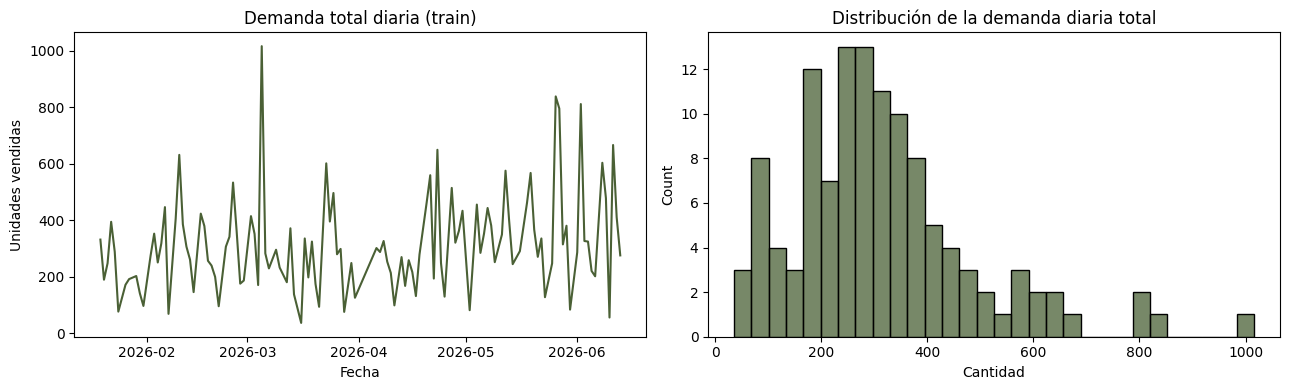

count     119.000000
mean      314.512605
std       172.085802
min        36.000000
25%       200.000000
50%       287.000000
75%       383.000000
max      1016.000000
Name: Cantidad, dtype: float64


In [10]:
demanda_diaria_total = train.groupby('Fecha')['Cantidad'].sum()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
demanda_diaria_total.plot(ax=axes[0], color=VERDE_OSCURO, title='Demanda total diaria (train)')
axes[0].set_ylabel('Unidades vendidas')
sns.histplot(demanda_diaria_total, bins=30, ax=axes[1], color=VERDE_OSCURO)
axes[1].set_title('Distribución de la demanda diaria total')
plt.tight_layout()
plt.show()

print(demanda_diaria_total.describe())

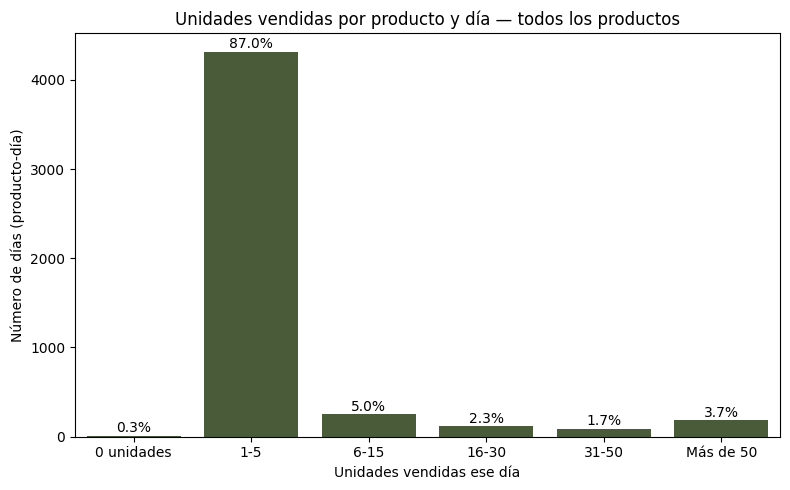

Producto-día con 0 ventas en train: 0.3%


In [11]:
# Distribución a nivel producto-día, agrupando en rangos simples (más fácil de leer que una escala logarítmica)
target_train = ventas_diarias[ventas_diarias['Fecha'] < fecha_corte].copy()

bins = [-1, 0, 5, 15, 30, 50, float('inf')]
labels = ['0 unidades', '1-5', '6-15', '16-30', '31-50', 'Más de 50']
target_train['Grupo'] = pd.cut(target_train['Unidades_Vendidas'], bins=bins, labels=labels)

conteo = target_train['Grupo'].value_counts().reindex(labels)
porcentaje = (conteo / conteo.sum() * 100).round(1)

plt.figure(figsize=(8,5))
ax = sns.barplot(x=conteo.index, y=conteo.values, color=VERDE_OSCURO)
plt.title('Unidades vendidas por producto y día — todos los productos')
plt.ylabel('Número de días (producto-día)')
plt.xlabel('Unidades vendidas ese día')

for i, (v, p) in enumerate(zip(conteo.values, porcentaje.values)):
    ax.text(i, v + max(conteo.values)*0.01, f'{p}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print(f'Producto-día con 0 ventas en train: {porcentaje["0 unidades"]}%')

**Observaciones:** la variable target a nivel producto-día tiene un porcentaje altísimo de ceros — esperable dado que estamos mirando aún los 1.012 productos, muchos con venta esporádica. Este problema se reduce mucho en la sección final, al quedarnos solo con los productos aptos para modelar.

<h2 style="color:#4A6035;">Relación entre las ventas y otras variables</h2>

Miramos cómo varía la demanda diaria total según el día de la semana y el mes, y su relación con el precio.

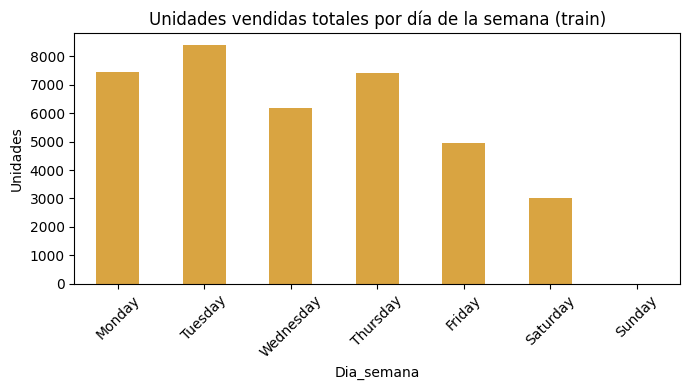

In [12]:
train['Dia_semana'] = pd.to_datetime(train['Fecha']).dt.day_name()
orden_dias = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

demanda_por_dia = train.groupby('Dia_semana')['Cantidad'].sum().reindex(orden_dias)

plt.figure(figsize=(7,4))
demanda_por_dia.plot(kind='bar', color=MOSTAZA)
plt.title('Unidades vendidas totales por día de la semana (train)')
plt.ylabel('Unidades')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

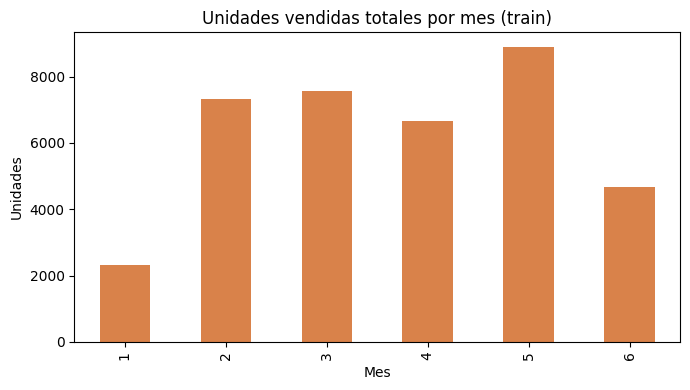

In [13]:
train['Mes'] = pd.to_datetime(train['Fecha']).dt.month

demanda_por_mes = train.groupby('Mes')['Cantidad'].sum()

plt.figure(figsize=(7,4))
demanda_por_mes.plot(kind='bar', color=NARANJA)
plt.title('Unidades vendidas totales por mes (train)')
plt.ylabel('Unidades')
plt.tight_layout()
plt.show()

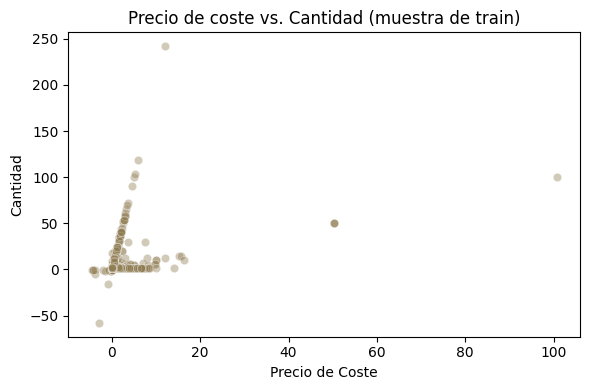

In [14]:
# Relación precio de coste vs cantidad vendida (a nivel línea de venta)
plt.figure(figsize=(6,4))
sns.scatterplot(data=train.sample(min(2000, len(train)), random_state=42), x='Precio de Coste', y='Cantidad', alpha=0.4, color=MARRON)
plt.title('Precio de coste vs. Cantidad (muestra de train)')
plt.tight_layout()
plt.show()

<h2 style="color:#4A6035;">Correlación entre variables numéricas</h2>

Revisamos la correlación entre las variables numéricas para detectar multicolinealidad (esperable entre Precio de Coste, Margen y Ventas).

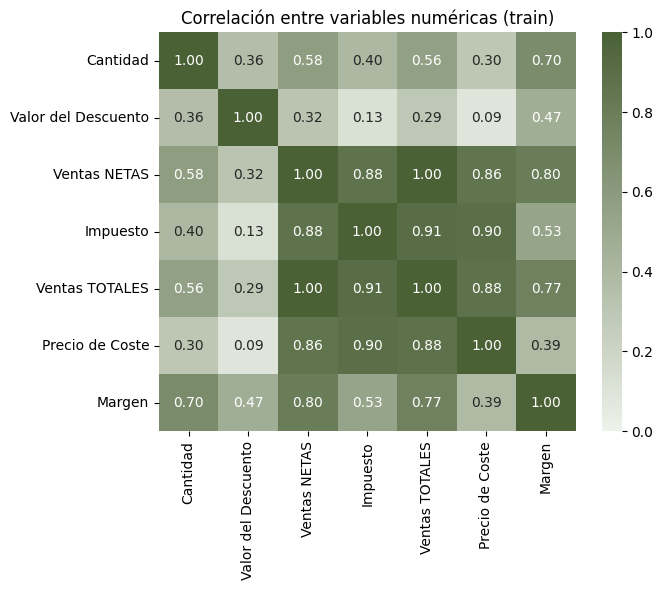

In [15]:
num_cols = ['Cantidad', 'Valor del Descuento', 'Ventas NETAS', 'Impuesto', 'Ventas TOTALES', 'Precio de Coste', 'Margen']
corr = train[num_cols].corr()

mapa_marca = sns.light_palette(VERDE_OSCURO, as_cmap=True)

plt.figure(figsize=(7,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap=mapa_marca, vmin=0, vmax=1)
plt.title('Correlación entre variables numéricas (train)')
plt.tight_layout()
plt.show()

**Observación esperada:** `Ventas TOTALES`, `Ventas NETAS`, `Impuesto` y `Precio de Coste` deberían mostrar alta colinealidad entre sí (todas derivan del precio de venta). No usarlas todas juntas como features del modelo.

<h2 style="color:#4A6035;">Detección de días con demanda atípica</h2>

Buscamos picos de demanda anómalos en la serie diaria total, usando el método IQR.

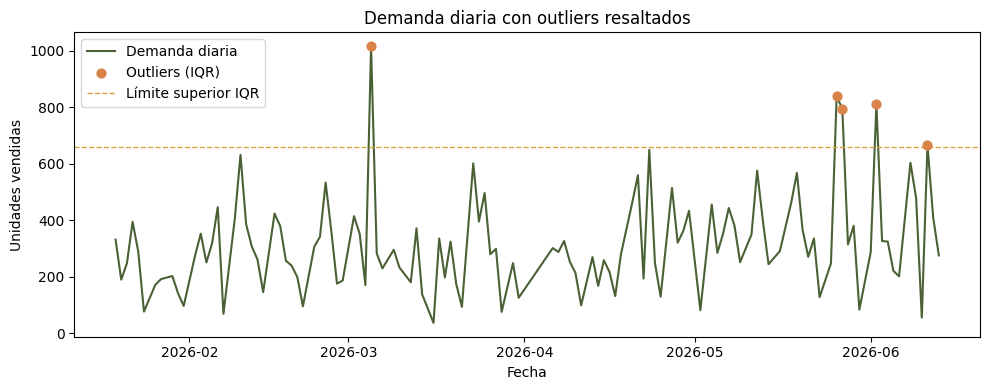

Límite superior (IQR): 658 unidades/día
Días considerados outlier: 5


Fecha
2026-03-05    1016.0
2026-05-26     838.0
2026-05-27     795.0
2026-06-02     811.0
2026-06-11     666.0
Name: Cantidad, dtype: float64

In [16]:
q1 = demanda_diaria_total.quantile(0.25)
q3 = demanda_diaria_total.quantile(0.75)
iqr = q3 - q1
limite_superior = q3 + 1.5 * iqr

outliers = demanda_diaria_total[demanda_diaria_total > limite_superior]

plt.figure(figsize=(10,4))
demanda_diaria_total.plot(color=VERDE_OSCURO, label='Demanda diaria')
plt.scatter(outliers.index, outliers.values, color=NARANJA, zorder=5, label='Outliers (IQR)', s=40)
plt.axhline(limite_superior, color=MOSTAZA, linestyle='--', linewidth=1, label='Límite superior IQR')
plt.title('Demanda diaria con outliers resaltados')
plt.ylabel('Unidades vendidas')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Límite superior (IQR): {limite_superior:.0f} unidades/día')
print(f'Días considerados outlier: {len(outliers)}')
outliers

**Observación:** conviene revisar manualmente estos días para distinguir entre "ruido" real y picos legítimos y repetibles (como campañas de Panini o vuelta al cole), que no deberían tratarse igual que un error de registro.

<h2 style="color:#4A6035;">Selección de productos para el modelado</h2>

De los 1.012 productos del dataset, la mayoría se venden de forma demasiado esporádica para modelar de forma fiable. Definimos 3 reglas para considerar un producto **apto**:

1. **Al menos 30 transacciones** en todo el periodo (para que el modelo no memorice en vez de aprender un patrón).
2. **Venta en al menos 15 de las 25 semanas** del periodo (para asegurar que haya muestras representativas también en test).
3. **Coeficiente de Variación (CV) semanal por debajo de 1.2** (desviación estándar / media de las unidades vendidas por semana), para descartar productos demasiado erráticos que metan ruido al modelo.

Un producto debe cumplir **las 3 reglas a la vez** para considerarse apto.

In [17]:
semanas_totales = df['Semana'].nunique()
todas_semanas = sorted(df['Semana'].unique())
print(f'Número total de semanas en el periodo: {semanas_totales}')

Número total de semanas en el periodo: 25


In [18]:
# Regla 1: número de transacciones (líneas de venta) por producto
transacciones = df.groupby('Producto').size()

# Regla 2: número de semanas distintas con venta, por producto
semanas_con_venta = df.groupby('Producto')['Semana'].nunique()

# Regla 3: CV semanal -> construimos la serie semanal completa (25 semanas, con 0 donde no hubo venta)
ventas_semanales = df.groupby(['Producto', 'Semana'])['Cantidad'].sum().reset_index()

productos_todos = df['Producto'].unique()
indice_semanal = pd.MultiIndex.from_product([productos_todos, todas_semanas], names=['Producto', 'Semana'])

panel_semanal = (
    ventas_semanales
    .set_index(['Producto', 'Semana'])
    .reindex(indice_semanal, fill_value=0)
    .reset_index()
)

def calcular_cv(x):
    return x.std() / x.mean() if x.mean() > 0 else np.inf

cv_semanal = panel_semanal.groupby('Producto')['Cantidad'].apply(calcular_cv)

# Juntamos las 3 métricas en una tabla resumen
resumen_seleccion = pd.DataFrame({
    'Transacciones': transacciones,
    'Semanas_con_venta': semanas_con_venta,
    'CV_semanal': cv_semanal
})

resumen_seleccion.head()

,Transacciones,Semanas_con_venta,CV_semanal
Producto,,,
10 Colores Mickey,1,1,5.000000
1200 Amarillo C-005,4,4,2.338536
1200 Azul C-010,5,5,2.041241
1200 Naranja Fluo C-066,3,3,2.763854
1200 Oro C-053,1,1,5.000000


In [19]:
# Aplicamos las 3 reglas
resumen_seleccion['Cumple_transacciones'] = resumen_seleccion['Transacciones'] >= 30
resumen_seleccion['Cumple_semanas'] = resumen_seleccion['Semanas_con_venta'] >= 15
resumen_seleccion['Cumple_CV'] = resumen_seleccion['CV_semanal'] < 1.2
resumen_seleccion['Apto_para_modelar'] = (
    resumen_seleccion['Cumple_transacciones']
    & resumen_seleccion['Cumple_semanas']
    & resumen_seleccion['Cumple_CV']
)

print('Productos que cumplen cada regla por separado:')
print(f'  >= 30 transacciones:      {resumen_seleccion["Cumple_transacciones"].sum()}')
print(f'  >= 15 de 25 semanas:      {resumen_seleccion["Cumple_semanas"].sum()}')
print(f'  CV semanal < 1.2:         {resumen_seleccion["Cumple_CV"].sum()}')
print()
print(f'Productos APTOS (cumplen las 3 reglas): {resumen_seleccion["Apto_para_modelar"].sum()} de {len(resumen_seleccion)}')

Productos que cumplen cada regla por separado:
  >= 30 transacciones:      46
  >= 15 de 25 semanas:      49
  CV semanal < 1.2:         43

Productos APTOS (cumplen las 3 reglas): 31 de 1012


In [20]:
productos_aptos = resumen_seleccion[resumen_seleccion['Apto_para_modelar']].sort_values('Transacciones', ascending=False)
productos_aptos

,Transacciones,Semanas_con_venta,CV_semanal,Cumple_transacciones,Cumple_semanas,Cumple_CV,Apto_para_modelar
Producto,,,,,,,
Copia A4 B/N,2605,25,0.440053,True,True,True,True
Doble Cara A4 B/N,988,24,0.730152,True,True,True,True
Copia A4 Color,670,24,0.664005,True,True,True,True
1ª Página,284,24,0.509124,True,True,True,True
Servicio menor a 1 hora,265,24,0.879170,True,True,True,True
Etiqueta Blanco y Negro,127,23,0.788035,True,True,True,True
Doble Cara A4 Color,115,23,0.930628,True,True,True,True
Encuadernación peq,91,22,1.026274,True,True,True,True
Navigator 80,89,22,0.622279,True,True,True,True


In [21]:
# Dataset final de target, filtrado a los productos aptos
productos_seleccionados = productos_aptos.index.tolist()

target_final = ventas_diarias[ventas_diarias['Producto'].isin(productos_seleccionados)].copy()

# Completar dias sin venta con 0, para el conjunto final de productos
todas_las_fechas = pd.date_range(df['Fecha'].min(), df['Fecha'].max(), freq='D').date
indice_final = pd.MultiIndex.from_product([productos_seleccionados, todas_las_fechas], names=['Producto', 'Fecha'])

target_final = (
    target_final
    .set_index(['Producto', 'Fecha'])
    .reindex(indice_final, fill_value=0)
    .reset_index()
)

print(f'Dataset final: {len(productos_seleccionados)} productos x {len(todas_las_fechas)} días = {len(target_final)} filas')
print(f'Porcentaje de ceros en el dataset final: {(target_final["Unidades_Vendidas"]==0).mean()*100:.1f}%')
target_final.head()

Dataset final: 31 productos x 169 días = 5239 filas
Porcentaje de ceros en el dataset final: 69.2%


,Producto,Fecha,Unidades_Vendidas
0,Copia A4 B/N,2026-01-19,133.0
1,Copia A4 B/N,2026-01-20,94.0
2,Copia A4 B/N,2026-01-21,92.0
3,Copia A4 B/N,2026-01-22,142.0
4,Copia A4 B/N,2026-01-23,51.0


**Conclusión de la selección:** de 1.012 productos, **31 cumplen las 3 reglas** y forman el universo final sobre el que se construirá el modelo. Es un conjunto bastante más exigente que un simple ranking por ingresos: combina volumen suficiente (transacciones), regularidad (semanas activas) y estabilidad (CV), que son justo los tres requisitos que hacen que un producto sea predecible de forma fiable.

**Entregable de esta sección:** `target_final` — dataset con Producto, Fecha y Unidades_Vendidas para los 31 productos aptos, listo para que el resto del equipo continúe con preprocesado y feature engineering.

In [22]:
# Guardamos el dataset final para que el compañero de preprocesado lo pueda cargar directamente
target_final.to_csv('../data_sample/target_final.csv', index=False)
print('Guardado: target_final.csv')

Guardado: target_final.csv
